In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm
import sys
sys.path.append('..')  # or sys.path.insert(0, '..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc, coeffs):
    p = np.poly1d(coeffs)
    # return np.polyval(coeffs, soc)
    return p(soc)

def step(state, I, p, coeffs):
    soc, U1 = state

    # Voltage at current state
    V_soc = V_soc_poly(soc, coeffs)
    V = V_soc - I*p['R0'] - U1

    # Evolve state
    soc_new = soc - (I * p['dt'] / p['Q'])
    U1_new = p['a']*U1 + p['R1']*(1 - p['a'])*I
    
    return (soc_new, U1_new), V, V_soc

def simulation(time, I, p, coeffs):
    soc = np.zeros(time.size)
    U1 = np.zeros(time.size)
    V = np.zeros(time.size)
    V_soc = np.zeros(time.size)
    I = np.asarray(I)
    if I.ndim == 0:                     # scalar - make constant
        I = np.ones_like(time) * I

    # initial state
    state = (1.0, 0.0)
    soc[0], U1[0] = state
    V_soc[0] = V_soc_poly(soc[0], coeffs)
    V[0] = V_soc[0] - I[0]*p['R0'] - U1[0]

    for t in range(1, len(time)):
        state, V[t], V_soc[t] = step(state, I[t], p, coeffs)
        soc[t], U1[t] = state

    return soc, U1, V, V_soc

In [3]:
def simulate_pybamm(I0):
    model = pybamm.lithium_ion.SPM()
    param = model.default_parameter_values
    def my_current(t, I0=I0):
        return I0
    
    param["Current function [A]"] = my_current

    param.process_model(model)
    geometry = model.default_geometry
    param.process_geometry(geometry)
    mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
    disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
    disc.process_model(model)
    t_eval = [0,3*3600]

    solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
    solution = solver.solve(model, t_eval)

    npc_v = solution.observe(model.variables['Voltage [V]'])
    npc = solution.observe(model.variables['Battery open-circuit voltage [V]'])
    npc_soc = solution.observe(model.variables['Average negative particle concentration'])
    return solution,model, npc_v, npc, npc_soc

def fit_func(solution, npc):
    t_ = np.linspace(0,solution['Time [s]'].entries[-1],101)
    coeffs_ = np.polyfit(np.linspace(1,0,101), npc(t_), 6)
    p = np.poly1d(coeffs_)  # Create polynomial function
    return p, coeffs_, t_


def estimate_soc_from_capacity(solution):
    initial_soc = 1  

    # Extract discharge capacity over time
    discharge_capacity = solution["Discharge capacity [A.h]"].data
    total_capacity = solution["Total lithium capacity [A.h]"].data[0]  # Scalar value
    voltage = solution["Battery open-circuit voltage [V]"].data

    # Calculate SOC as an array over time
    soc = initial_soc - (discharge_capacity / total_capacity)

    # Extract time array
    time = solution["Time [s]"].data

    # Ensure time and SOC arrays have the same shape
    if len(time) != len(soc):
        min_length = min(len(time), len(soc))
        time = time[:min_length]
        soc = soc[:min_length]

    return soc, time


2400.0


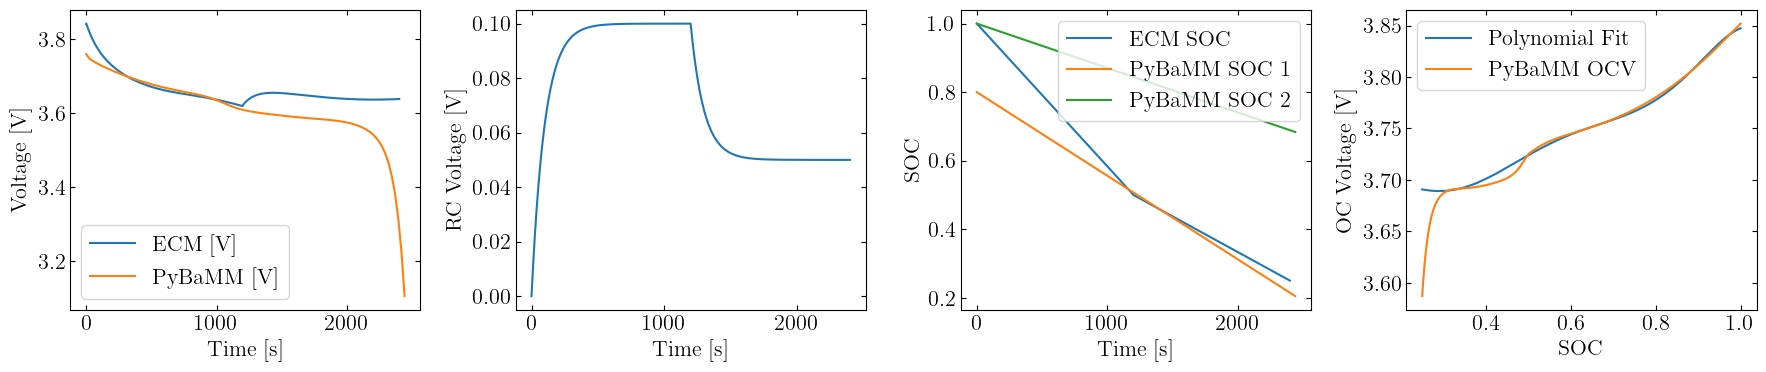

In [4]:
# Parameters
params = dict(
    R0=0.005, # Ohm
    R1=0.1, # Ohm
    C1=1000, # F
    dt=1, # time step in seconds
    I0=1. # Current in A
)
params['Q'] = 2400 # Capacity in As (1Ah = 3600 As)
# params['Q'] = params['I0'] * params['t_tot'] # Capacity in As (1Ah = 3600 As)
params['a'] = np.exp(-params['dt'] / (params['R1'] * params['C1'])) # Time constant for the RC circuit


solution, model, npc_v, npc, npc_soc = simulate_pybamm(I0=params['I0'])
p, coeffs_, t_ = fit_func(solution, npc)
pybamm_soc, pybamm_time = estimate_soc_from_capacity(solution)
# print(npc_soc(t_))


params['t_tot'] = params['Q'] / params['I0']  # Total simulation time based on capacity and current
print(params['t_tot'])
time = np.arange(0, params['t_tot'], params['dt']) # 1 hour of simulation

I = np.zeros_like(time)
I[0:1200] = params['I0']
I[1200:] = 0.5
charge_used = np.cumsum(I) * params['dt']  # Cumulative charge used over time
idx_end = np.searchsorted(charge_used, params['Q'])  # Find index where charge used exceeds capacity


soc, U1, V, V_soc = simulation(time, I, params, coeffs_)

# Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 4))
ax1.plot(time, V, label='ECM [V]')
ax1.plot(t_, npc_v(t_), label='PyBaMM [V]')
ax1.legend()
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, U1, label='RC Voltage [V]')
ax2.set_ylabel('RC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='ECM SOC')
ax3.plot(t_, npc_soc(t_), label='PyBaMM SOC 1')
ax3.plot(pybamm_time, pybamm_soc, label='PyBaMM SOC 2')
ax3.legend()
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, p(soc), label='Polynomial Fit')
ax4.plot(soc, npc(time), label='PyBaMM OCV')
ax4.set_xlabel('SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.legend()
plt.tight_layout()

# print(soc, npc(time).shape)

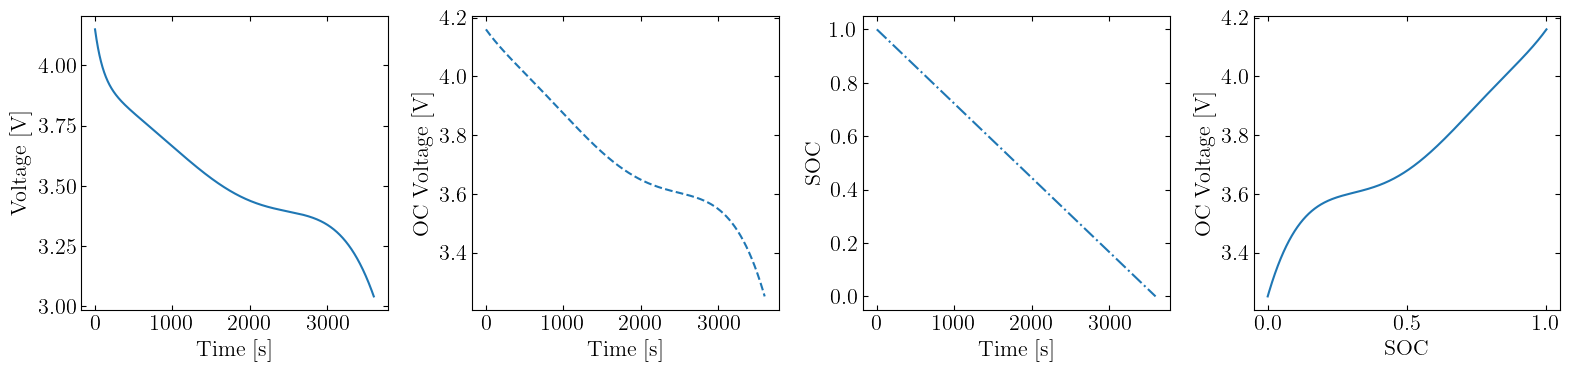

In [5]:
# Parameters
Q = 2*3600 # Capacity As    1Ah = 3600 As
R0 = 0.005 # Ohm
R1 = 0.1 # Ohm
C1 = 1000 # F
dt = 1 # time step in seconds
I = 2 # Current in A

time = np.arange(0, 3600, dt) # 1 hour of simulation
a = np.exp(-dt / (R1 * C1)) # Time constant for the RC circuit

# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc):
    coeffs = [3.25, 3.29, -11.96, 19.33, -8.90, -4.65, 3.80]
    return np.polyval(coeffs[::-1], soc)

V = np.zeros(time.size) # Voltage
U1 = np.zeros(time.size) # Voltage across C1
soc = np.zeros(time.size) # State of Charge
V_soc = np.zeros(time.size) # OC voltage

# Initialize arrays
U1[0] = 0 # Initial voltage across C1   
soc[0] = 1 # Initial SOC (fully charged)
V_soc[0] = V_soc_poly(soc[0]) # Initial OC voltage
V[0] = V_soc[0] - I*R0 - U1[0] # Initial voltage in V

def evolve(soc, V_soc, U1, V):
    soc[t] = soc[t-1] - (I * dt / Q) # Update SOC
    V_soc[t] = V_soc_poly(soc[t])
    U1[t] = a*U1[t-1] + R1*(1 - a)*I # Voltage across R1
    V[t] = V_soc[t] - I*R0 - U1[t] # Terminal voltage
    return soc, V_soc, U1, V

# Simulation loop
for t in range(1, len(time)):
    soc, V_soc, U1, V = evolve(soc, V_soc, U1, V)

# Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
ax1.plot(time, V, label='Terminal Voltage [V]')
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, V_soc, label='OC Voltage [V]', linestyle='--')
ax2.set_ylabel('OC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='State of Charge (SOC)', linestyle='-.')
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, V_soc, label='OC Voltage vs SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.set_xlabel('SOC')
plt.tight_layout()